In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import scipy.stats as stats
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
from datetime import datetime
import os

pd.set_option('display.max_columns', None)

In [28]:
goodreads_export = f'./data/goodreads_library_export.csv'

if os.path.isfile(goodreads_export):
    print(f'{goodreads_export} already exists')
else:
    # Export my books
    options = Options()
    options.add_experimental_option("prefs", {
    "download.default_directory": r"C:\Users\Alex\Documents\testing\goodreads-ranker\data",
    "download.prompt_for_download": False,
    "download.directory_upgrade": True,
    "safebrowsing.enabled": True
    })

    driver = webdriver.Chrome(options=options)
    driver.get('https://www.goodreads.com/ap/signin?language=en_US&openid.assoc_handle=amzn_goodreads_web_na&openid.claimed_id=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0%2Fidentifier_select&openid.identity=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0%2Fidentifier_select&openid.mode=checkid_setup&openid.ns=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0&openid.pape.max_auth_age=0&openid.return_to=https%3A%2F%2Fwww.goodreads.com%2Fap-handler%2Fsign-in')

    username_field = driver.find_element(By.NAME, 'email')
    password_field = driver.find_element(By.NAME, 'password')
    username_field.send_keys('alejandro.shutov@gmail.com')
    password_field.send_keys('Alejo26alejo26')
    password_field.send_keys(Keys.RETURN)

    WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.CLASS_NAME, "homePrimaryColumn")))
    driver.get('https://www.goodreads.com/review/import')
    time.sleep(2)

    goodreads_current_date = datetime.now().strftime('%m/%d/%Y')
    file = driver.find_element(By.CLASS_NAME, 'fileList')
    if goodreads_current_date not in file.text:
        export_button = driver.find_element(By.CLASS_NAME, 'js-LibraryExport')
        export_button.click()

    WebDriverWait(driver, 60).until(EC.presence_of_element_located((By.CLASS_NAME, "fileList")))

    while True:
        file = driver.find_element(By.CLASS_NAME, 'fileList')
        if goodreads_current_date in file.text:
            # find the link and click it
            link = file.find_element(By.TAG_NAME, 'a')
            link.click()
            time.sleep(1)
            break
        else:
            time.sleep(5)

    driver.quit()

./data/goodreads_library_export.csv already exists


In [29]:
df1 = pd.read_csv(goodreads_export)
df1['Original Publication Year'] = df1['Original Publication Year'].fillna(df1['Year Published'])

df1 = df1.drop(['Author l-f', 'Additional Authors', 'ISBN', 'ISBN13', 'Binding', 'My Review', 'Date Read', 'Date Added', 'Bookshelves with positions', 'Bookshelves', 'Exclusive Shelf', 'Spoiler', 'Private Notes', 'Year Published', 'Read Count', 'Owned Copies'], axis=1)

with open(f'./data/book_ids.txt', 'w', encoding='utf-8') as f:
    for index, row in df1.iterrows():
        f.write(f'{row["Book Id"]}\n')

In [30]:
!python get_books.py --book_ids_path .\data\ --output_directory_path .\data\

# # In jupyter, the progress indcators are printed when the cell stops running.
# # Run the command in the terminal to see progress

505
3
2024-04-20 15:25:47.833099 get_books.py: Scraping 32839245...
2024-04-20 15:25:47.833099 get_books.py: #1 out of 508 books
============================= Skipping book 32839245 because the script tag was not found.
2024-04-20 15:25:48.776757 get_books.py: Scraping 17869520...
2024-04-20 15:25:48.776757 get_books.py: #2 out of 508 books
============================= Skipping book 17869520 because the script tag was not found.
2024-04-20 15:25:49.559062 get_books.py: Scraping 48579471...
2024-04-20 15:25:49.559062 get_books.py: #3 out of 508 books
============================= Skipping book 48579471 because the script tag was not found.
2024-04-20 15:25:50.339488 get_books.py:

🎉 Success! All book metadata scraped. 🎉

Metadata files have been output to /.\data
Goodreads scraping run time = ⏰ 0:00:02.528286 ⏰


### Once you have scraped for more info

In [31]:
current_month = datetime.now().strftime('%m-%Y')
df2 = pd.read_csv(f'./data/{current_month}_goodreads_scraped.csv')
df = df1.merge(df2, left_on='Book Id', right_on='book_id', how='inner')
df = df.drop(['Book Id', 'Title', 'average_rating'], axis=1)
df = df.rename(columns={'Author': 'author', 'Number of Pages': 'num_pages', 'Original Publication Year': 'year', 'My Rating': 'my_rating', 'Publisher': 'publisher', 'Average Rating': 'average_rating'})

df.rating_distribution = df.rating_distribution.apply(eval)
df.genres = df.genres.apply(eval)
df['age'] = int(datetime.now().strftime('%Y')) - df.year
median_age = df.age.median()
df.age = df.age.fillna(median_age)
median_num_pages = df.num_pages.median()
df.num_pages = df.num_pages.fillna(median_num_pages)
df.my_rating = df.my_rating.replace(0, np.nan)

def normalize_dict(d):
    max_value = max(d.values())
    return {f'num_{k}star_rating': v / max_value for k, v in d.items()}

df = pd.concat([df, df['rating_distribution'].apply(normalize_dict).apply(pd.Series)], axis=1)

# Elaborate rating distribution

### Normalize ratings

In [32]:
def fit_quadratic(row):
    x = np.array([1, 2, 3, 4, 5])
    a, b, c = np.polyfit(x, row, 2)
    return pd.Series([2*a, b, c])

# Apply the function to each row
coefficients = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].apply(fit_quadratic, axis=1)

# Create the new columns from the result
df['2a'], df['b'], df['c'] = coefficients[0], coefficients[1], coefficients[2]

scaler = MinMaxScaler()
df['num_ratings_log'] = np.log1p(df['num_ratings'])
df['age_log'] = np.log1p(df['age'])
df['num_pages_log'] = np.log1p(df['num_pages'])
df['average_rating_norm'] = scaler.fit_transform(df[['average_rating']])
df['average_rating_norm'] = df['average_rating_norm'] - 0.5

In [33]:
# # The idea is that if a book has only a few ratings, the Bayesian adjusted rating will be closer to the overall mean rating, while if a book has many ratings, the Bayesian adjusted rating will be closer to the book’s raw average rating.
# def bayesian_rating(df):
#   mean = df['average_rating'].mean()
#   std = df['average_rating'].std()
#   df['bayesian_rating'] = (df['average_rating'] * df['num_ratings'] + mean * std**2) / (df['num_ratings'] + std**2)
#   return df

# df = bayesian_rating(df)

In [34]:
# Calculate the mean and standard deviation of the ratings
df['mean_rating'] = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].mean(axis=1)
df['std_rating'] = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].std(axis=1)

# Calculate the standard error of the mean
df['sem_score'] = df['std_rating'] / np.sqrt(df['num_ratings_log'])
df = df.drop(['mean_rating', 'std_rating'], axis=1)

In [35]:
# # df['weighted_rating'] = (df.average_rating * df.num_ratings_log) / (df.num_pages_log)
# df['relative_weighted_rating'] = (df.average_rating_norm * df.num_ratings_log) / (df.num_pages_log)
# df['sem_rating'] = df.average_rating / (df.num_pages_log * df.sem_score)
df['relative_sem_rating'] = df.average_rating_norm / (df.num_pages_log * df.sem_score)

# df['trend_rating'] = (df['2a']-df.b+df.c)/df.num_pages_log
# df['trend_rating'] = (df['2a']-df.b)/df.num_pages_log # almost identical to the last
df['trend_rating'] = (df['2a'])/df.num_pages_log # favors promising books with fewer reviews

# Final ranking
# df['weighted_rank'] = df['weighted_rating'].rank(method='min')
# df['relative_weighted_rank'] = df['relative_weighted_rating'].rank(method='min')
# df['sem_rank'] = df['sem_rating'].rank(method='min')
df['relative_sem_rank'] = df['relative_sem_rating'].rank(method='min')
df['trend_rank'] = df['trend_rating'].rank(method='min')
df['final_rating'] = df.trend_rank + df.relative_sem_rank # + df.relative_weighted_rank

In [36]:
df = df[['book_id', 'book_title', 'book_series', 'author', 'publisher', 'num_pages', 'year', 'my_rating', 'num_ratings', 'num_reviews', 'average_rating', 'rating_distribution', 'genres', 'relative_sem_rating', 'trend_rating','final_rating']]

In [37]:
df.sort_values(by='final_rating', ascending=False).head(30)
# df.sort_values(by='relative_sem_rating', ascending=False)
# df.sort_values(by='trend_rating', ascending=False)
df.loc[df['my_rating'].isnull(), :].sort_values(by='final_rating', ascending=False).head(30)

,book_id,book_title,book_series,author,publisher,num_pages,year,my_rating,num_ratings,num_reviews,average_rating,rating_distribution,genres,relative_sem_rating,trend_rating,final_rating
410,464260,The Fire Next Time,NaN,James Baldwin,Vintage,106.0,1963.0,NaN,100599,9103,4.54,"{'5': 65262, '4': 27147, '3': 6429, '2': 1159,...","[Nonfiction, Classics, Essays, Race, History, ...",0.650564,0.042425,1007.0
127,50196744,Know My Name,NaN,Chanel Miller,Viking,384.0,2019.0,NaN,200282,27716,4.71,"{'5': 154346, '4': 35537, '3': 8363, '2': 1524...","[Nonfiction, Memoir, Audiobook, Feminism, Biog...",0.692000,0.039790,1006.0
401,20342617,Just Mercy,NaN,Bryan Stevenson,One World,336.0,2014.0,NaN,231929,25710,4.63,"{'5': 165694, '4': 51595, '3': 10899, '2': 231...","[Nonfiction, Memoir, Social Justice, Race, Pol...",0.633754,0.038300,1001.0
125,23463279,Designing Data-Intensive Applications,NaN,Martin Kleppmann,O'Reilly,562.0,2015.0,NaN,8383,769,4.71,"{'5': 6424, '4': 1591, '3': 294, '2': 47, '1':...","[Programming, Technology, Computer Science, So...",0.558170,0.037487,999.0
145,50611052,The Rise and Triumph of the Modern Self: Cultu...,NaN,Carl R. Trueman,Crossway,432.0,2020.0,NaN,4919,1016,4.58,"{'5': 3352, '4': 1202, '3': 259, '2': 72, '1':...","[Philosophy, History, Nonfiction, Cultural, Ch...",0.464427,0.034961,982.0
415,5055380,Jiu-Jitsu University,NaN,Saulo Ribeiro,Victory Belt Publishing,368.0,2008.0,NaN,1302,59,4.58,"{'5': 885, '4': 315, '3': 81, '2': 13, '1': 8}","[Martial Arts, Nonfiction, Sports, Fitness, He...",0.438740,0.035393,977.0
77,426504,Ficciones,NaN,Jorge Luis Borges,Grove Press,174.0,1944.0,NaN,67915,4236,4.42,"{'5': 40659, '4': 18070, '3': 6721, '2': 1793,...","[Fiction, Short Stories, Magical Realism, Fant...",0.457722,0.033577,977.0
163,33986067,Deep Learning with Python,NaN,François Chollet,Manning,350.0,2017.0,NaN,1263,128,4.57,"{'5': 845, '4': 321, '3': 78, '2': 12, '1': 7}","[Programming, Artificial Intelligence, Compute...",0.432491,0.035048,974.0
17,1617,Night,Book 1 in the The Night Trilogy series,Elie Wiesel,Hill & Wang,120.0,1956.0,NaN,1246177,37948,4.37,"{'5': 697420, '4': 372045, '3': 133992, '2': 2...","[Nonfiction, Classics, Memoir, Holocaust, Biog...",0.478761,0.032208,974.0
102,20510512,Socratic Selling: How to Ask the Questions Tha...,NaN,Kevin Daley,McGraw-Hill,228.0,1995.0,NaN,40,6,4.68,"{'5': 30, '4': 7, '3': 3, '2': 0, '1': 0}","[Business, Nonfiction]",0.402906,0.041189,973.0


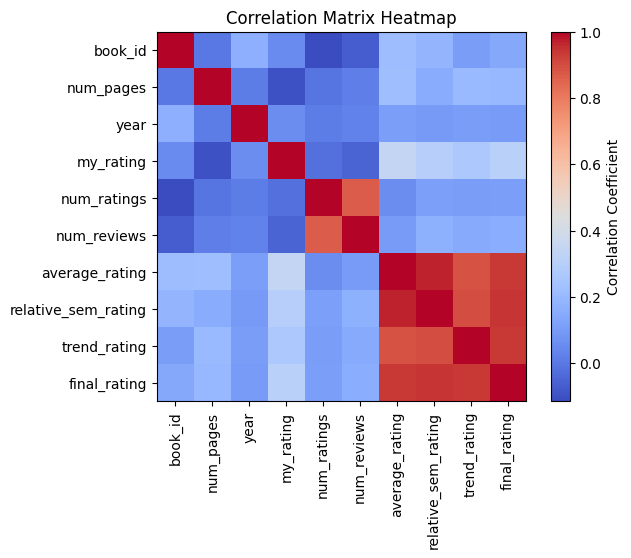

In [38]:
correlation_matrix = df.drop(['genres', 'rating_distribution', 'author', 'book_title', 'book_series', 'publisher'], axis=1).corr()

plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix Heatmap')

# Display the plot
plt.show()

In [39]:
# correlation_matrix.sort_values(by='2a', ascending=False)

# Elaborate genres and rating_dist columns

In [40]:
df_exploded = df.explode('genres')
genres_dummies = pd.get_dummies(df_exploded['genres'])

df_exploded = pd.concat([df_exploded, genres_dummies], axis=1)

agg_dict = {col: 'first' for col in df_exploded.columns.difference(['genres']+list(genres_dummies.columns))}
agg_dict.update({col: 'sum' for col in genres_dummies.columns})

df_genres = df_exploded.groupby('book_id', as_index=False).agg(agg_dict)


In [41]:
# drop uncommon genres
mean_genres = pd.Series(genres_dummies.mean(), index=genres_dummies.columns)
for column in df_genres.columns:
    if column in mean_genres.index and mean_genres.loc[column] < mean_genres.mean():
        df_genres = df_genres.drop(column, axis=1)

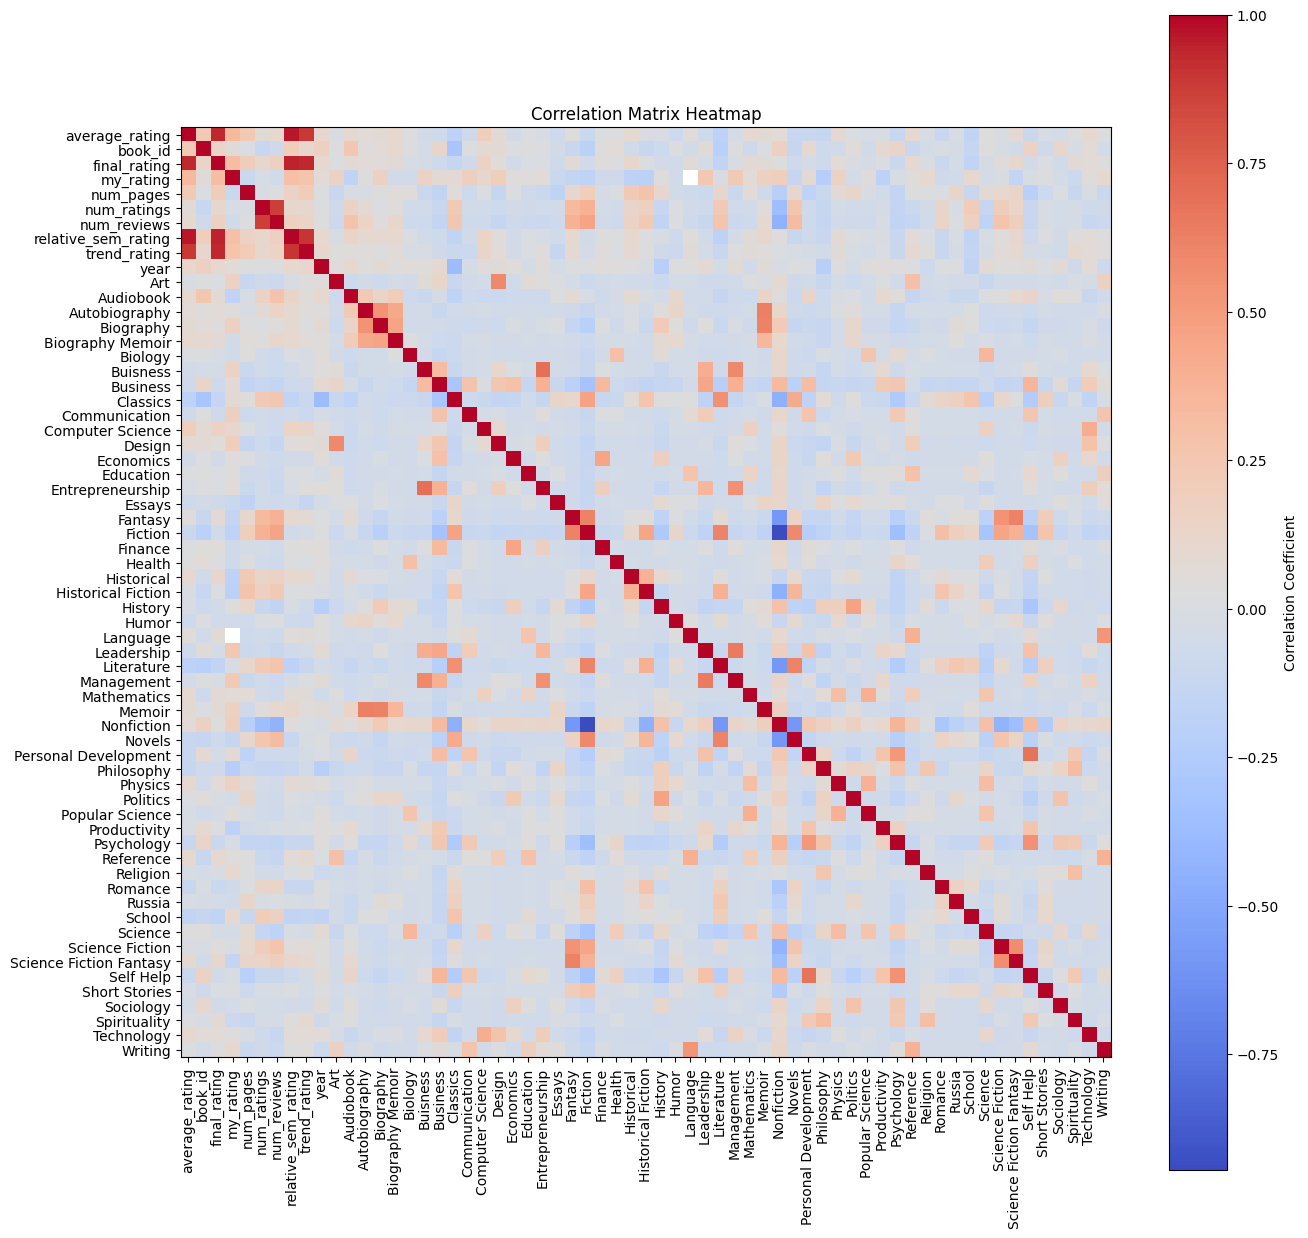

In [42]:
correlation_matrix = df_genres.drop(['rating_distribution', 'author', 'book_title', 'book_series', 'publisher'], axis=1).corr()
plt.figure(figsize=(15,15))
plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix Heatmap')

# Display the plot
plt.show()

In [457]:
correlation_matrix.sort_values(by='my_rating', ascending=False).head(30)


,average_rating,book_id,final_rating,my_rating,num_pages,num_ratings,num_reviews,relative_sem_rating,trend_rating,year,Art,Audiobook,Autobiography,Biography,Biography Memoir,Biology,Buisness,Business,Classics,Communication,Computer Science,Design,Economics,Education,Entrepreneurship,Essays,Fantasy,Fiction,Finance,Health,Historical,Historical Fiction,History,Humor,Language,Leadership,Literature,Management,Mathematics,Memoir,Nonfiction,Novels,Personal Development,Philosophy,Physics,Politics,Popular Science,Productivity,Psychology,Reference,Religion,Romance,Russia,School,Science,Science Fiction,Science Fiction Fantasy,Self Help,Sociology,Spirituality,Technology,Writing
my_rating,0.361535,0.060295,0.334062,1.000000,-0.099481,-0.005221,-0.039273,0.346346,0.306525,0.087893,0.154947,-0.155043,-0.011323,0.131559,-0.049286,-0.049286,0.154947,0.071780,0.044698,0.177390,0.108841,0.191048,0.042391,0.042391,0.060766,-0.100578,-0.120934,-0.163067,-0.070165,-0.070165,-0.185882,-0.185882,-0.011323,-0.049286,NaN,0.237778,-0.006225,0.222110,0.060766,0.131559,0.163067,-0.124250,0.072112,-0.222919,0.154947,-0.040573,0.042391,-0.179033,-0.024179,0.032081,0.154947,-0.070165,-0.049286,0.042391,-0.025820,0.008674,-0.146303,-0.010336,-0.040573,-0.073598,0.042391,0.098528
average_rating,1.000000,0.203427,0.935747,0.361535,0.220571,0.045704,0.094811,0.965529,0.890532,0.106990,-0.010252,0.085985,0.061498,0.078157,0.100118,0.007924,-0.010293,-0.066633,-0.185360,-0.068001,0.194227,0.069785,-0.041476,-0.013325,0.016188,-0.073355,0.025953,-0.101334,0.016363,0.028054,0.083930,-0.016238,-0.002114,-0.082340,0.046767,-0.060785,-0.198918,-0.018474,0.087530,0.072946,0.071313,-0.115010,-0.111384,-0.127891,0.089062,0.005948,-0.019371,-0.020971,-0.124354,0.110788,-0.014921,-0.105494,-0.016019,-0.152706,0.031133,-0.006006,0.093114,-0.101033,-0.065512,0.009034,0.100434,0.024857
relative_sem_rating,0.965529,0.181445,0.941014,0.346346,0.149084,0.096998,0.159472,1.000000,0.900137,0.096074,-0.021725,0.123526,0.089981,0.093954,0.104926,-0.000541,-0.013901,-0.064520,-0.159433,-0.056483,0.145726,0.037998,-0.043007,-0.018167,0.011651,-0.050246,0.079809,-0.066328,0.022542,0.017123,0.104601,-0.001172,-0.015092,-0.073115,0.047020,-0.041659,-0.199966,-0.014785,0.054463,0.103203,0.051025,-0.106145,-0.072572,-0.104877,0.070084,0.004516,-0.019536,-0.012012,-0.115209,0.071255,0.004818,-0.105871,-0.011258,-0.153212,-0.007605,0.038664,0.112766,-0.071196,-0.069363,0.042527,0.067730,0.027774
final_rating,0.935747,0.127540,1.000000,0.334062,0.192803,0.097063,0.150552,0.941014,0.936413,0.101097,-0.007603,0.077448,0.063061,0.034900,0.071220,-0.019430,-0.002054,-0.070586,-0.141099,-0.068722,0.153799,0.042367,-0.035476,-0.016038,0.029140,-0.068589,0.063134,-0.054080,0.040413,0.009492,0.106241,-0.003555,-0.041151,-0.052348,0.056934,-0.029955,-0.159687,0.000138,0.069864,0.051373,0.028376,-0.072432,-0.035153,-0.070956,0.065086,-0.003934,-0.028624,-0.000170,-0.106597,0.102718,-0.015567,-0.100768,-0.034240,-0.154470,-0.023242,0.039679,0.116541,-0.044377,-0.078405,0.072678,0.067676,0.035737
trend_rating,0.890532,0.090568,0.936413,0.306525,0.204757,0.100009,0.144885,0.900137,1.000000,0.104718,0.027312,0.047556,0.051418,0.013990,0.062133,-0.017190,0.012080,-0.060337,-0.103103,-0.093077,0.135257,0.053990,-0.040493,-0.015701,0.057757,-0.124722,0.065009,-0.030604,0.037697,-0.000471,0.087059,0.012621,-0.069364,-0.090447,0.058752,-0.033071,-0.119510,0.010091,0.052420,0.035094,0.002334,-0.016141,-0.024073,-0.048867,0.053909,-0.013024,-0.038674,-0.006147,-0.110468,0.088209,0.027280,-0.107362,-0.031187,-0.145503,-0.025537,0.063040,0.095484,-0.028966,-0.079263,0.094214,0.062940,0.052581
Leadership,-0.060785,0.086123,-0.029955,0.237778,-0.079235,-0.068950,-0.099227,-0.041659,-0.033071,0.065705,-0.061931,-0.018249,-0.063527,0.014807,-0.053352,-0.065091,0.359380,0.422354,-0.161406,0.227474,-0.055160,-0.045936,-0.071064,-0.060299,0.316522,-0.065091,-0.096616,-0.159516,0.012537,-0.055160,-0.068131,-0.073905,-0.1437

In [269]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(df.sort_values(by='2a', ascending=False))